# Introduction
In this colab, a 1V Rail-to-Rail input stage is simulated using NGSpice
The reference paper can be accessed at [1-V rail-to-rail operational amplifiers in standard CMOS technology
](https://ieeexplore.ieee.org/document/818918/)
In next 3 cells, we are just installing the required modules and skywater files
(I have followed Stefano Schippers' tutorial (https://xschem.sourceforge.io/stefan/xschem_man/video_tutorials/install_xschem_sky130_and_ngspice.mp4) to install and build the skywater files and then uploaded the minimal 100mb subset here. I strongly recommend that you run Stefano's setup at your end to build files from original skywater repo as the files that I am uploading have been moved across many OS multiple times and might get inadvertently corrupted. If there is a better way to communicate the above information to emphasize this github repo is not my original work as well as the risks involved, do let me know!)

In [7]:
%%capture
! python --version  # Pyspice works with python  3.9 or lower
!pip install -q gdown
!git clone https://github.com/ShlokVaibhav/SkyWater130nm_subset.git
!wget https://raw.githubusercontent.com/ShlokVaibhav/RTR_LS/main/Res_amp/res_amp_working.spice


In [8]:
%%capture
!pip install matplotlib
!pip install numpy
!pip install scipy

In [9]:
%%capture
import sys
import subprocess
import platform

def install_ngspice():
    system = platform.system()
    if system == "Linux":
        # Google Colab
        subprocess.run(["apt-get", "update"], check=True)
        subprocess.run(["apt-get", "-y", "install", "ngspice"], check=True)

    elif system == "Windows":
        # Conda-based Windows
        subprocess.run(
            ["conda", "install", "-y", "-c", "conda-forge", "ngspice"],
            shell=True
        )
    else:
        raise RuntimeError("Unsupported OS")

install_ngspice()


# Schematic and Results
The schematic to be simulated:(Generated using Xschem and skywater130)
The scheme is straightforward, we use a negative feedback on the input common-mode voltage to generate two level-shifted inputs that are clamped to a VREF=300mV, this is then passed to the input pair of actual amp.


In [10]:
subprocess.call("ngspice -b -o output.log res_amp_working.spice", shell=True)

0

The key nodes- The applied input, the output and the level shifted inputs and outputs compared with the reference are plotted. The Shifted inputs do get clamped to VREF=300mV while the actual input and output swing almost rail-to-rail. The clamping is underwhelming as I am still in process of characterizing skywater130 devices and this is a bare-minimum design

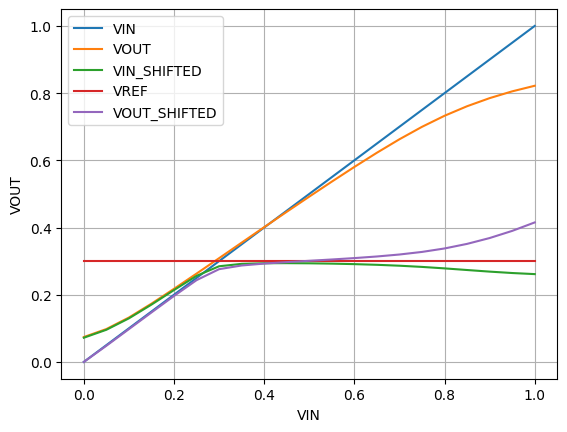

In [11]:
#The key node voltages can be added
import numpy as np
import matplotlib.pyplot as plt
columns = ["VIN", "VOUT", "VREF", "VIN_SHIFTED", "VOUT_SHIFTED"]
file_name = "res_dc_ana"

def Gen_sweep_plot(columns, file_name):
  data = np.loadtxt(file_name)
  VIN = data[:, 1]   # first column
  VOUT = data[:, 3]   # first column
  VREF = data[:, 5]  # second column
  VIN_SHIFTED = data[:, 7]  # second column
  VOUT_SHIFTED = data[:, 9]  # second column
  plt.plot(VIN, VIN, label="VIN")
  plt.plot(VIN, VOUT, label="VOUT")
  plt.plot(VIN, VIN_SHIFTED, label="VIN_SHIFTED")
  plt.plot(VIN, VREF, label="VREF")
  plt.plot(VIN, VOUT_SHIFTED, label="VOUT_SHIFTED")
  plt.xlabel("VIN")
  plt.ylabel("VOUT")
  plt.legend()
  plt.grid(True)
  plt.show()
  return

Gen_sweep_plot(columns, file_name)


The input error is plotted now:
(It is not flat in the middle because the skywater transistors have not yet been characterized)

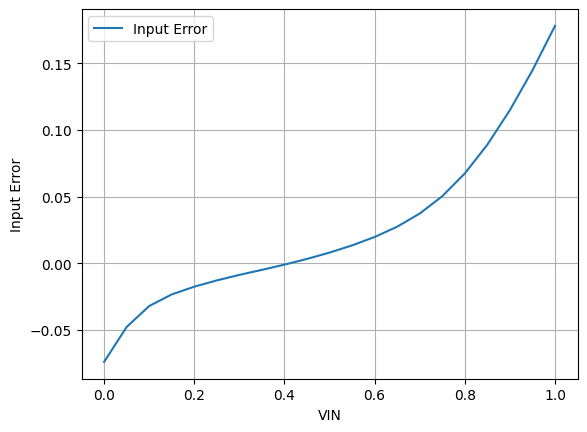

In [12]:
def Plot_input_error(columns, file_name):
  data = np.loadtxt(file_name)
  VIN = data[:, 1]   # first column
  VOUT = data[:, 3]   # first column
  VREF = data[:, 5]  # second column
  VIN_SHIFTED = data[:, 7]  # second column
  VOUT_SHIFTED = data[:, 9]  # second column
  plt.plot(VIN, VIN-VOUT, label="Input Error")
  plt.xlabel("VIN")
  plt.ylabel("Input Error")
  plt.legend()
  plt.grid(True)
  plt.show()
  return

Plot_input_error(columns, file_name)
